In [1]:
#04_dowhy.ipynb

In [20]:
# Imports and paths

from pathlib import Path
import pandas as pd
import numpy as np

from dowhy import CausalModel

BASE = Path("../..")   # change if needed
PROCESSED = BASE / "data" / "processed" / "CY-Bench-02"
RESULTS = BASE / "data" / "results" / "CY-Bench-02"
RESULTS.mkdir(parents=True, exist_ok=True)

panel_path = PROCESSED / "wheat_IN_panel_full_year.csv"
panel = pd.read_csv(panel_path)

dag_path = RESULTS / "wheat_dag.dot"
with open(dag_path, "r") as f:
    wheat_dag_dot = f.read()

panel.shape

In [3]:
# Choose one first treatment-outcome question
# First pass: effect of root-zone soil moisture on yield

analysis_cols = [
    "adm_id", "harvest_year",
    "yield",
    "avg_rsm", "avg_ssm",
    "avg_ndvi", "avg_fpar",
    "avg_tavg", "avg_prec", "avg_vpd", "avg_cwb",
    "awc", "bulk_density", "drainage_class",
    "latitude", "longitude", "region_area"
]

analysis_cols = [c for c in analysis_cols if c in panel.columns]
df = panel[analysis_cols].copy()

df.shape

In [4]:
# Clean rows for the first treatment-outcome run

treatment = "avg_ndvi"
outcome = "yield"

needed = [treatment, outcome]
df = df.dropna(subset=needed).copy()

for c in df.columns:
    if c != "adm_id" and c != "drainage_class":
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[treatment, outcome]).reset_index(drop=True)
df.shape

In [5]:
# Optional: encode drainage_class if present

if "drainage_class" in df.columns:
    df["drainage_class"] = df["drainage_class"].astype("category")
    df["drainage_class_code"] = df["drainage_class"].cat.codes.replace(-1, np.nan)
    df = df.drop(columns=["drainage_class"])

In [6]:
# Keep a simple estimation dataset

estimation_cols = [
    "yield",
    "avg_rsm", "avg_ssm",
    "avg_ndvi", "avg_fpar",
    "avg_tavg", "avg_prec", "avg_vpd", "avg_cwb",
    "awc", "bulk_density",
    "latitude", "longitude", "region_area",
    "harvest_year"
]

if "drainage_class_code" in df.columns:
    estimation_cols.append("drainage_class_code")

estimation_cols = [c for c in estimation_cols if c in df.columns]
df_est = df[estimation_cols].dropna().reset_index(drop=True)

df_est.shape

In [7]:
# Build a DoWhy model from the DAG

model = CausalModel(
    data=df_est,
    treatment=treatment,
    outcome=outcome,
    graph=wheat_dag_dot
)

model

/home/weird-alien/My-proj/Causal-Agro/Causal-Crop-Yield-Forecasting/.venv/lib/python3.12/site-packages/dowhy/causal_model.py:581: UserWarning: 4 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


In [8]:
# Identify the estimand

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
estimate_lr = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)


In [9]:
# Alternative estimator: propensity-score-based methods need binary treatment,
# so for now we keep treatment continuous and stay with regression.
# Later we can binarize avg_rsm into low/high moisture if scientifically justified.

In [10]:
# Refutation 1: random common cause

refute_random = model.refute_estimate(
    identified_estimand,
    estimate_lr,
    method_name="random_common_cause"
)

print(refute_random)

Refute: Add a random common cause
Estimated effect:0.09962435739080133
New effect:0.09899101131582945
p value:0.92



In [11]:
# Refutation 2: placebo treatment

refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate_lr,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.09962435739080133
New effect:0.009174873471714542
p value:0.96



In [12]:
# Refutation 3: subset validation

refute_subset = model.refute_estimate(
    identified_estimand,
    estimate_lr,
    method_name="data_subset_refuter"
)

print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.09962435739080133
New effect:0.13372390013680524
p value:0.8400000000000001



In [13]:
# Save a compact results table

results_rows = [
    {
        "treatment": treatment,
        "outcome": outcome,
        "estimator": "backdoor.linear_regression",
        "estimate_value": getattr(estimate_lr, "value", np.nan),
        "estimand": str(identified_estimand),
        "refute_random": str(refute_random),
        "refute_placebo": str(refute_placebo),
        "refute_subset": str(refute_subset),
    }
]

dowhy_results = pd.DataFrame(results_rows)
dowhy_results

,treatment,outcome,estimator,estimate_value,estimand,refute_random,refute_placebo,refute_subset
0,avg_ndvi,yield,backdoor.linear_regression,0.099624,Estimand type: EstimandType.NONPARAMETRIC_ATE\...,Refute: Add a random common cause\nEstimated e...,Refute: Use a Placebo Treatment\nEstimated eff...,Refute: Use a subset of data\nEstimated effect...


In [14]:
# Save results

dowhy_results_path = RESULTS / f"wheat_IN_dowhy_{treatment}_to_yield.csv"
dowhy_results.to_csv(dowhy_results_path, index=False)

dowhy_results_path

PosixPath('../../data/results/CY-Bench-02/wheat_IN_dowhy_avg_ndvi_to_yield.csv')

In [15]:
# Template for a second analysis:
# treatment = "avg_ssm"
# outcome = "yield"
# Then rerun Cells 4 onward.

In [16]:
#avg_ssm -> yield.

#avg_rsm -> yield.

#avg_ndvi -> yield.

#avg_fpar -> yield.

,treatment,estimate,refute_random,refute_placebo,refute_subset
0,SSM,-0.358534,0.98,0.9,0.84
1,RSM,0.002283,0.76,0.98,0.92
2,FPAR,0.083577,0.98,0.98,1.0
3,NDVI,0.099624,0.92,0.96,0.8400000000000001


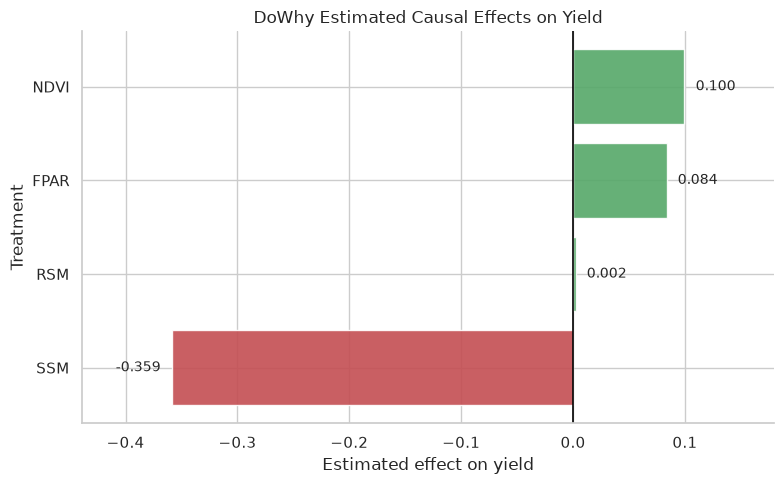

In [22]:
# Plot DoWhy results from the saved CSV files in RESULTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dowhy_files = {
    "SSM": RESULTS / "wheat_IN_dowhy_avg_ssm_to_yield.csv",
    "RSM": RESULTS / "wheat_IN_dowhy_avg_rsm_to_yield.csv",
    "FPAR": RESULTS / "wheat_IN_dowhy_avg_fpar_to_yield.csv",
    "NDVI": RESULTS / "wheat_IN_dowhy_avg_ndvi_to_yield.csv",
}

rows = []
for label, path in dowhy_files.items():
    if path.exists():
        df_tmp = pd.read_csv(path)
        if not df_tmp.empty:
            row = df_tmp.iloc[0]
            rows.append({
                "treatment": label,
                "estimate": float(row["estimate_value"]),
                "refute_random": str(row["refute_random"]).split("p value:")[-1].strip(),
                "refute_placebo": str(row["refute_placebo"]).split("p value:")[-1].strip(),
                "refute_subset": str(row["refute_subset"]).split("p value:")[-1].strip(),
            })
    else:
        print(f"Missing file: {path}")

plot_df = pd.DataFrame(rows).sort_values("estimate").reset_index(drop=True)
display(plot_df)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#c44e52" if x < 0 else "#55a868" for x in plot_df["estimate"]]
bars = ax.barh(plot_df["treatment"], plot_df["estimate"], color=colors, alpha=0.9)

ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Estimated effect on yield")
ax.set_ylabel("Treatment")
ax.set_title("DoWhy Estimated Causal Effects on Yield")

xmin = plot_df["estimate"].min()
xmax = plot_df["estimate"].max()
pad = 0.08 * max(1, abs(xmin), abs(xmax))
ax.set_xlim(xmin - pad, xmax + pad)

for bar, val in zip(bars, plot_df["estimate"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        ax.text(x + 0.01, y, f"{val:.3f}", va="center", ha="left", fontsize=10)
    else:
        ax.text(x - 0.01, y, f"{val:.3f}", va="center", ha="right", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../figures/CY-Bench-02/DoWhy.png", bbox_inches='tight', dpi=300)